In [ ]:
import scipy.stats as sc
sc.norm(160,1.63)

In [ ]:
import numpy as np
x=np.linspace(120,250)
display(x)

array([120.        , 122.65306122, 125.30612245, 127.95918367,
       130.6122449 , 133.26530612, 135.91836735, 138.57142857,
       141.2244898 , 143.87755102, 146.53061224, 149.18367347,
       151.83673469, 154.48979592, 157.14285714, 159.79591837,
       162.44897959, 165.10204082, 167.75510204, 170.40816327,
       173.06122449, 175.71428571, 178.36734694, 181.02040816,
       183.67346939, 186.32653061, 188.97959184, 191.63265306,
       194.28571429, 196.93877551, 199.59183673, 202.24489796,
       204.89795918, 207.55102041, 210.20408163, 212.85714286,
       215.51020408, 218.16326531, 220.81632653, 223.46938776,
       226.12244898, 228.7755102 , 231.42857143, 234.08163265,
       236.73469388, 239.3877551 , 242.04081633, 244.69387755,
       247.34693878, 250.        ])

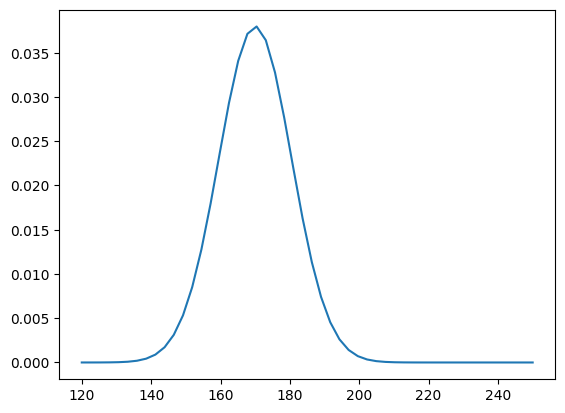

In [ ]:
import matplotlib.pyplot as plt

plt.plot(x,sc.norm(170,10.5).pdf(x))
#probability distribution function

In [ ]:
'''
#Set directory
from google.colab import drive
drive.mount('/content/drive/',force_remount=True)
path = '/content/drive/My Drive/data'
'''

"\n#Set directory\nfrom google.colab import drive\ndrive.mount('/content/drive/',force_remount=True)\npath = '/content/drive/My Drive/data'\n"

In [ ]:
#Question1 What is a probability of P(W|Height=177)=?

In [ ]:
import pandas as pd
#df =pd.read_csv(path + '/Weight_Height_M_W.csv')
#df = pd.read_csv("Weight_Height_M_W.csv")
#print(df)

In [20]:
import io
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Weight_Height_M_W.csv')

In [21]:
df

,Height,Weight,gender
0,159.7415,57.2608,W
1,157.2365,53.1664,W
2,158.8578,49.5106,W
3,157.4017,54.1508,W
4,156.2003,52.2173,W
...,...,...,...
96,172.1863,63.6287,M
97,168.9630,55.1719,M
98,172.8701,53.6238,M
99,171.1873,62.8852,M


In [22]:
display(df.groupby(['gender']).mean())
display(df.groupby(['gender']).std())

,Height,Weight
gender,,
M,168.627387,60.359704
W,158.060584,54.534971


,Height,Weight
gender,,
M,2.983280,8.435698
W,1.959757,5.914949


In [23]:
df.loc[df['gender']=='W','Weight'].mean()


np.float64(54.53497142857143)

In [24]:
#P(W|Height=177) =P(Height=177|W)*P(W)/(P(Height=177|W)*P(W)+P(Height=177|M)*P(M))

#P(Height=177|W)
PH_W=sc.norm(	158.060584,1.959757).pdf(177)
#P(Height=177|M)
PH_M=sc.norm(	168.627387,2.983280	).pdf(177)

# PH_W = P(Height=177|W)
# P(W) = 0.5
# P(M) = 0.5
# P(Height=177) = (P(Height=177|W)*P(W)+P(Height=177|M)*P(M))
print(PH_W*0.5/(PH_W*0.5+PH_M*0.5))
print(PH_M*0.5/(PH_W*0.5+PH_M*0.5))

4.0940256546711138e-19
1.0


In [25]:
np.mean(df[df['gender']=='W']['Height'])

np.float64(158.06058367346938)

In [26]:
df

,Height,Weight,gender
0,159.7415,57.2608,W
1,157.2365,53.1664,W
2,158.8578,49.5106,W
3,157.4017,54.1508,W
4,156.2003,52.2173,W
...,...,...,...
96,172.1863,63.6287,M
97,168.9630,55.1719,M
98,172.8701,53.6238,M
99,171.1873,62.8852,M


In [27]:
#Question2 What is a probability of P(W|Height=177, Weight=60)=?

In [28]:
#P(W|Height=177, weight=60) = P((height=177,weight=60) | w)* p(w) / P(height=177,weight=60)
# assume height and weight is not related
# P((height=177,weight=60) | w) = P(height=177|w) * P(weight60=|w) / p(height=177,weight=60)
# we can't calculate  p(height=177,weight=06) from our data set directly since we assume the

In [29]:
df['gender_code']=1*(df['gender']=='W')

In [30]:
# woman wegith
mean_ww = df.loc[df['gender']=='W',"Weight"].mean()
sd_ww = df.loc[df['gender']=='W',"Weight"].std()
print(mean_ww,sd_ww)
prob_ww = sc.norm(mean_ww,sd_ww).pdf(60)

# woman height
mean_wh = df.loc[df['gender']=='W',"Height"].mean()
sd_wh = df.loc[df['gender']=='W',"Height"].std()
print(mean_wh,sd_wh)
prob_wh = sc.norm(mean_wh,sd_wh).pdf(177)

# man weight
mean_mw = df.loc[df['gender']=='M',"Weight"].mean()
sd_mw = df.loc[df['gender']=='M',"Weight"].std()
print(mean_mw,sd_mw)
prob_mw = sc.norm(mean_mw,sd_mw).pdf(60)

# man height
mean_mh = df.loc[df['gender']=='M',"Height"].mean()
sd_mh = df.loc[df['gender']=='M',"Height"].std()
print(mean_mh,sd_mh)
prob_mh = sc.norm(mean_mh,sd_mh).pdf(177)

54.53497142857143 5.914949412294241
158.06058367346938 1.959757330252368
60.35970384615385 8.435697544805402
168.6273865384615 2.9832799946176385


In [31]:
PH_W=sc.norm(	158.060584,1.959757).pdf(177)
PW_W=sc.norm(54.534971, 5.914949).pdf(60)
print(PH_W, PW_W)

1.0666047448692053e-21 0.04401391506377992


In [32]:
p_height = prob_wh*0.5 + prob_mh*0.5
p_weight = prob_mw*0.5 + prob_ww*0.5
print(p_height,p_weight)

0.0013026350571463795 0.045631546980469784


In [33]:
print(PH_W*PW_W/(p_height*p_weight))

## ans of P(W|Height=177, Weight=60)=?

7.897789570229247e-19


In [34]:
PH_M * PH_W

np.float64(2.7787947065732134e-24)

In [35]:
print(df)

       Height   Weight gender  gender_code
0    159.7415  57.2608      W            1
1    157.2365  53.1664      W            1
2    158.8578  49.5106      W            1
3    157.4017  54.1508      W            1
4    156.2003  52.2173      W            1
..        ...      ...    ...          ...
96   172.1863  63.6287      M            0
97   168.9630  55.1719      M            0
98   172.8701  53.6238      M            0
99   171.1873  62.8852      M            0
100  168.6423  75.0807      M            0

[101 rows x 4 columns]


In [36]:
import random
random.seed(10)
train=random.sample(range(101), 80)
df['train']=0
df.loc[train,'train']=1


In [37]:
data_train=df[df['train']==1]
data_test=df[df['train']==0]


In [38]:
print(data_train)

       Height   Weight gender  gender_code  train
0    159.7415  57.2608      W            1      1
1    157.2365  53.1664      W            1      1
2    158.8578  49.5106      W            1      1
3    157.4017  54.1508      W            1      1
4    156.2003  52.2173      W            1      1
..        ...      ...    ...          ...    ...
92   171.8703  59.1178      M            0      1
94   166.2576  60.6964      M            0      1
96   172.1863  63.6287      M            0      1
99   171.1873  62.8852      M            0      1
100  168.6423  75.0807      M            0      1

[80 rows x 5 columns]


In [39]:
print(data_test)

      Height   Weight gender  gender_code  train
6   158.1349  62.6261      W            1      0
7   157.6258  53.3276      W            1      0
13  158.1024  53.8214      W            1      0
16  160.8178  44.0806      W            1      0
21  156.2048  51.8346      W            1      0
29  153.0009  56.2988      W            1      0
39  154.7324  56.8593      W            1      0
43  154.9356  55.1209      W            1      0
47  156.7690  55.1672      W            1      0
50  166.8767  76.6268      M            0      0
55  168.4807  63.2346      M            0      0
64  174.8635  60.4340      M            0      0
68  171.8468  52.8492      M            0      0
70  168.6678  57.0914      M            0      0
71  170.3384  61.1965      M            0      0
74  167.6619  64.3665      M            0      0
78  172.2689  52.4876      M            0      0
93  172.0235  62.2197      M            0      0
95  170.6254  61.3887      M            0      0
97  168.9630  55.171

In [40]:
mean_WM=data_train.loc[data_train['gender']=='M','Weight'].mean()
sd_WM =data_train.loc[data_train['gender']=='M','Weight'].std()

In [41]:
mean_WW=data_train.loc[data_train['gender']=='W','Weight'].mean()
sd_WW =data_train.loc[data_train['gender']=='W','Weight'].std()

In [42]:
mean_HM=data_train.loc[data_train['gender']=='M','Height'].mean()
sd_HM =data_train.loc[data_train['gender']=='M','Height'].std()

In [43]:
mean_HW=data_train.loc[data_train['gender']=='W','Height'].mean()
sd_HW =data_train.loc[data_train['gender']=='W','Height'].std()

In [44]:
PW=sc.norm(mean_WW,sd_WW).pdf(data_test['Weight'])*sc.norm(mean_HW,sd_HW).pdf(data_test['Height'])*0.5


In [45]:
PM=sc.norm(mean_WM,sd_WM).pdf(data_test['Weight'])*sc.norm(mean_HM,sd_HM).pdf(data_test['Height'])*0.5


In [46]:
prob_w=PW/(PW+PM)

In [47]:
prob_m=PM/(PW+PM)

In [51]:
np.set_printoptions(precision=3,suppress=True)
predicts = np.array([np.round(prob_w,2) ,np.round(prob_m,2) ,data_test['gender']]).T
display(predicts)

array([[1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [0.96, 0.04, 'W'],
       [1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [1.0, 0.0, 'W'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M'],
       [0.0, 1.0, 'M']], dtype=object)

In [52]:
print(len(predicts))

21


In [54]:
## this is the correct prediction count
count = 0;
for predict in predicts:
  if predict[0] > 0.5 and predict[2] == 'W':
    count = count + 1
  elif predict[1] > 0.5 and predict[2] == 'M':
    count = count + 1
print(len(predicts)-count)

0
